# Análise Exploratória de Dados — Risco de Crédito

Este notebook apresenta a análise exploratória das bases fornecidas para o problema de **previsão de inadimplência**.

O objetivo é entender a estrutura, qualidade e o poder preditivo das variáveis disponíveis antes de partir para a modelagem, respondendo a três perguntas centrais:

1. Como as bases se relacionam e qual a qualidade dos dados (nulos, tipos, duplicidades)?
2. Como construir a variável-alvo (`inadimplente`) e qual sua distribuição?
3. Quais variáveis cadastrais, financeiras e temporais parecem estar associadas ao risco de inadimplência?

**Regra de negócio (inadimplência):** um pagamento é considerado inadimplente quando ocorre com **atraso ≥ 5 dias** em relação à `DATA_VENCIMENTO`, ou quando **não há pagamento registrado** (`DATA_PAGAMENTO` nulo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = "../data"


## 1. Carregamento e Visão Geral das Bases

Carregamos as quatro bases fornecidas (delimitador `;`) e inspecionamos, para cada uma: dimensão, tipos de dados, primeiras linhas, estatísticas descritivas e volume de valores nulos.

In [2]:
df_cadastral = pd.read_csv(f"{DATA_DIR}/base_cadastral.csv", sep=";")
df_info = pd.read_csv(f"{DATA_DIR}/base_info.csv", sep=";")
df_pag_dev = pd.read_csv(f"{DATA_DIR}/base_pagamentos_desenvolvimento.csv", sep=";")
df_pag_test = pd.read_csv(f"{DATA_DIR}/base_pagamentos_teste.csv", sep=";")

bases = {
    "base_cadastral": df_cadastral,
    "base_info": df_info,
    "base_pagamentos_desenvolvimento": df_pag_dev,
    "base_pagamentos_teste": df_pag_test,
}

In [3]:
def overview(df: pd.DataFrame, name: str) -> None:
    print(f"===== {name} =====")
    print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas".replace(",", "."))
    print()
    print("Tipos de dados:")
    print(df.dtypes)
    print()
    print("Primeiras linhas:")
    display(df.head())
    print()
    print("Estatísticas descritivas:")
    display(df.describe(include="all").T)
    print()
    nulls = df.isnull().sum()
    pct = (nulls / len(df) * 100).round(2)
    null_table = pd.DataFrame({"n_nulos": nulls, "pct_nulos": pct})
    null_table = null_table[null_table["n_nulos"] > 0].sort_values("pct_nulos", ascending=False)
    print("Valores nulos (apenas colunas com nulos):")
    if null_table.empty:
        print("Nenhuma coluna com valores nulos.")
    else:
        display(null_table)
    print("\n")

### 1.1 `base_cadastral`

In [4]:
overview(df_cadastral, "base_cadastral")

===== base_cadastral =====
Shape: 1.315 linhas x 8 colunas

Tipos de dados:
ID_CLIENTE             int64
DATA_CADASTRO            str
DDD                      str
FLAG_PF                  str
SEGMENTO_INDUSTRIAL      str
DOMINIO_EMAIL            str
PORTE                    str
CEP_2_DIG                str
dtype: object

Primeiras linhas:


,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62



Estatísticas descritivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_CLIENTE,1315.0,NaN,NaN,NaN,4637945205782817792.0,2667893963532407296.0,8784237149961904.0,2307709078237718016.0,4714187554103729152.0,6973809039343120384.0,9206030810342980608.0
DATA_CADASTRO,1315,777,2000-08-15,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DDD,1078,79,11,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_PF,66,1,X,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEGMENTO_INDUSTRIAL,1232,3,Serviços,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOMINIO_EMAIL,1285,6,YAHOO,392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PORTE,1274,3,MEDIO,522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CEP_2_DIG,1315,90,13,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Valores nulos (apenas colunas com nulos):


,n_nulos,pct_nulos
FLAG_PF,1249,94.98
DDD,237,18.02
SEGMENTO_INDUSTRIAL,83,6.31
PORTE,41,3.12
DOMINIO_EMAIL,30,2.28


### 1.2 `base_info`

In [5]:
overview(df_info, "base_info")

===== base_info =====
Shape: 24.401 linhas x 4 colunas

Tipos de dados:
ID_CLIENTE              int64
SAFRA_REF                 str
RENDA_MES_ANTERIOR    float64
NO_FUNCIONARIOS       float64
dtype: object

Primeiras linhas:


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0



Estatísticas descritivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_CLIENTE,24401.0,NaN,NaN,NaN,4668214159782658048.0,2669294096683301376.0,8784237149961904.0,2347028805684088320.0,4795152981525833728.0,7061868716439557120.0,9206030810342980608.0
SAFRA_REF,24401,40,2021-09,717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RENDA_MES_ANTERIOR,23684.0,NaN,NaN,NaN,288751.395035,211594.788834,105.0,133866.25,240998.5,392501.75,1682759.0
NO_FUNCIONARIOS,23149.0,NaN,NaN,NaN,117.799646,21.464574,0.0,106.0,118.0,131.0,198.0



Valores nulos (apenas colunas com nulos):


,n_nulos,pct_nulos
NO_FUNCIONARIOS,1252,5.13
RENDA_MES_ANTERIOR,717,2.94


### 1.3 `base_pagamentos_desenvolvimento`

In [6]:
overview(df_pag_dev, "base_pagamentos_desenvolvimento")

===== base_pagamentos_desenvolvimento =====
Shape: 77.414 linhas x 7 colunas

Tipos de dados:
ID_CLIENTE                  int64
SAFRA_REF                     str
DATA_EMISSAO_DOCUMENTO        str
DATA_PAGAMENTO                str
DATA_VENCIMENTO               str
VALOR_A_PAGAR             float64
TAXA                      float64
dtype: object

Primeiras linhas:


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99



Estatísticas descritivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_CLIENTE,77414.0,NaN,NaN,NaN,4662270147931493376.0,2665719403408342528.0,8784237149961904.0,2369364892942408192.0,4817816966382229504.0,6969348581033924608.0,9206030810342980608.0
SAFRA_REF,77414,35,2021-05,2531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DATA_EMISSAO_DOCUMENTO,77414,1040,2021-05-16,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DATA_PAGAMENTO,77414,921,2021-02-17,315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DATA_VENCIMENTO,77414,955,2019-03-06,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VALOR_A_PAGAR,76244.0,NaN,NaN,NaN,46590.777166,46433.92958,0.1,18765.3625,34758.695,60933.8375,4400000.0
TAXA,77414.0,NaN,NaN,NaN,6.789623,1.798225,4.99,5.99,5.99,6.99,11.99



Valores nulos (apenas colunas com nulos):


,n_nulos,pct_nulos
VALOR_A_PAGAR,1170,1.51


### 1.4 `base_pagamentos_teste`

In [7]:
overview(df_pag_test, "base_pagamentos_teste")

===== base_pagamentos_teste =====
Shape: 12.275 linhas x 6 colunas

Tipos de dados:
ID_CLIENTE                  int64
SAFRA_REF                     str
DATA_EMISSAO_DOCUMENTO        str
DATA_VENCIMENTO               str
VALOR_A_PAGAR             float64
TAXA                      float64
dtype: object

Primeiras linhas:


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99



Estatísticas descritivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_CLIENTE,12275.0,NaN,NaN,NaN,4670820326741473280.0,2667868015813813760.0,8784237149961904.0,2308217045093677056.0,4850936440093751296.0,6964108750473070592.0,9206030810342980608.0
SAFRA_REF,12275,5,2021-10,2673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DATA_EMISSAO_DOCUMENTO,12275,150,2021-11-04,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DATA_VENCIMENTO,12275,141,2021-09-06,293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VALOR_A_PAGAR,12144.0,NaN,NaN,NaN,65883.258575,55919.40497,6.9,26712.335,49665.21,87029.3625,830000.0
TAXA,12275.0,NaN,NaN,NaN,6.807271,1.835351,4.99,5.99,5.99,6.99,11.99



Valores nulos (apenas colunas com nulos):


,n_nulos,pct_nulos
VALOR_A_PAGAR,131,1.07


### 1.5 Unicidade de `ID_CLIENTE` em `base_cadastral`

A `base_cadastral` deveria ter uma linha por cliente. Verificamos abaixo se `ID_CLIENTE` é de fato uma chave única nessa base.

In [8]:
n_linhas = len(df_cadastral)
n_ids_unicos = df_cadastral["ID_CLIENTE"].nunique()
print(f"Linhas: {n_linhas}")
print(f"IDs únicos: {n_ids_unicos}")
print("ID_CLIENTE é chave única em base_cadastral:", n_linhas == n_ids_unicos)

Linhas: 1315
IDs únicos: 1315
ID_CLIENTE é chave única em base_cadastral: True


## 2. Construção da Variável-Alvo

Construímos a variável `inadimplente` a partir da `base_pagamentos_desenvolvimento`, aplicando a regra de negócio:

- `dias_atraso = DATA_PAGAMENTO - DATA_VENCIMENTO` (em dias)
- `inadimplente = 1` se `dias_atraso >= 5` **ou** `DATA_PAGAMENTO` nulo
- `inadimplente = 0` caso contrário

In [9]:
df_pag_dev["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(df_pag_dev["DATA_EMISSAO_DOCUMENTO"])
df_pag_dev["DATA_PAGAMENTO"] = pd.to_datetime(df_pag_dev["DATA_PAGAMENTO"])
df_pag_dev["DATA_VENCIMENTO"] = pd.to_datetime(df_pag_dev["DATA_VENCIMENTO"])

df_pag_dev["dias_atraso"] = (df_pag_dev["DATA_PAGAMENTO"] - df_pag_dev["DATA_VENCIMENTO"]).dt.days
df_pag_dev["inadimplente"] = (
    (df_pag_dev["dias_atraso"] >= 5) | (df_pag_dev["DATA_PAGAMENTO"].isna())
).astype(int)

n_pagamento_nulo = df_pag_dev["DATA_PAGAMENTO"].isna().sum()
print(f"Registros sem DATA_PAGAMENTO nesta base: {n_pagamento_nulo}")
if n_pagamento_nulo == 0:
    print("-> Neste conjunto de desenvolvimento, todos os pagamentos possuem data registrada;")
    print("   a inadimplência é definida inteiramente pelo critério de atraso (>= 5 dias).")

Registros sem DATA_PAGAMENTO nesta base: 0
-> Neste conjunto de desenvolvimento, todos os pagamentos possuem data registrada;
   a inadimplência é definida inteiramente pelo critério de atraso (>= 5 dias).


### 2.1 Distribuição da variável-alvo

,contagem,percentual
inadimplente,,
Adimplente (0),71978,92.98
Inadimplente (1),5436,7.02


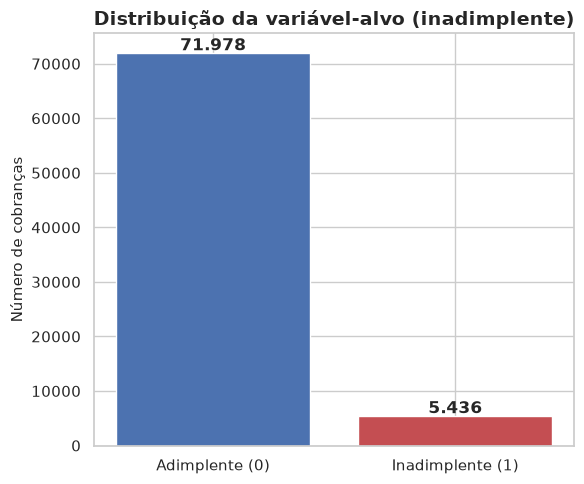

Taxa geral de inadimplência: 7.02%


In [10]:
target_dist = df_pag_dev["inadimplente"].value_counts().rename({0: "Adimplente (0)", 1: "Inadimplente (1)"})
target_pct = (df_pag_dev["inadimplente"].value_counts(normalize=True) * 100).rename(
    {0: "Adimplente (0)", 1: "Inadimplente (1)"}
)
target_table = pd.DataFrame({"contagem": target_dist, "percentual": target_pct.round(2)})
display(target_table)

fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#4C72B0", "#C44E52"]
ax.bar(target_table.index, target_table["contagem"], color=colors)
for i, v in enumerate(target_table["contagem"]):
    ax.text(i, v + 500, f"{v:,}".replace(",", "."), ha="center", fontweight="bold")
ax.set_title("Distribuição da variável-alvo (inadimplente)")
ax.set_ylabel("Número de cobranças")
plt.tight_layout()
plt.show()

print(f"Taxa geral de inadimplência: {target_table.loc['Inadimplente (1)', 'percentual']:.2f}%")

### 2.2 Distribuição de `dias_atraso` (pagamentos realizados)

Analisamos a distribuição do atraso apenas para os registros em que houve pagamento (`DATA_PAGAMENTO` não nulo). A linha tracejada marca o corte de 5 dias usado para definir inadimplência.

count    77414.000000
mean        -0.171429
std         25.229477
min      -2661.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        869.000000
Name: dias_atraso, dtype: float64


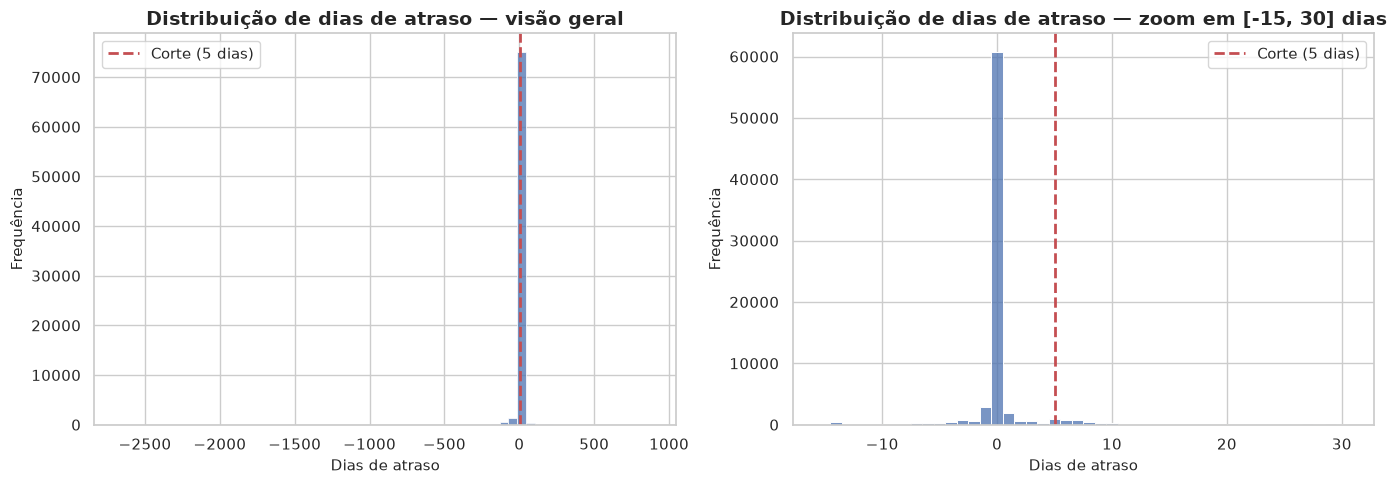

Observação: há valores extremos de dias_atraso (mínimo -2661 e máximo 869 dias), que podem indicar erros de cadastro de datas e merecem tratamento na etapa de modelagem.


In [11]:
pagos = df_pag_dev[df_pag_dev["DATA_PAGAMENTO"].notna()].copy()
print(pagos["dias_atraso"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(pagos["dias_atraso"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].axvline(5, color="#C44E52", linestyle="--", linewidth=2, label="Corte (5 dias)")
axes[0].set_title("Distribuição de dias de atraso — visão geral")
axes[0].set_xlabel("Dias de atraso")
axes[0].set_ylabel("Frequência")
axes[0].legend()

faixa = pagos[pagos["dias_atraso"].between(-15, 30)]
sns.histplot(faixa["dias_atraso"], bins=46, ax=axes[1], color="#4C72B0", discrete=True)
axes[1].axvline(5, color="#C44E52", linestyle="--", linewidth=2, label="Corte (5 dias)")
axes[1].set_title("Distribuição de dias de atraso — zoom em [-15, 30] dias")
axes[1].set_xlabel("Dias de atraso")
axes[1].set_ylabel("Frequência")
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    "Observação: há valores extremos de dias_atraso (mínimo "
    f"{pagos['dias_atraso'].min()} e máximo {pagos['dias_atraso'].max()} dias), "
    "que podem indicar erros de cadastro de datas e merecem tratamento na etapa de modelagem."
)

## 3. Análise das Variáveis Cadastrais

Cruzamos `base_pagamentos_desenvolvimento` (nível de cobrança, já com a variável-alvo) com `base_cadastral` (nível de cliente) para avaliar a taxa de inadimplência por categoria de cada variável cadastral.

Para evitar conclusões precipitadas em categorias com poucas observações, nos gráficos de "top categorias" consideramos apenas categorias com pelo menos 30 cobranças.

In [12]:
df_pag_cad = df_pag_dev.merge(df_cadastral, on="ID_CLIENTE", how="left")
print(f"Registros após merge com base_cadastral: {len(df_pag_cad)} (esperado: {len(df_pag_dev)})")

Registros após merge com base_cadastral: 77414 (esperado: 77414)


In [13]:
CAT_VARS = ["FLAG_PF", "PORTE", "SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "CEP_2_DIG", "DDD"]
MIN_COUNT = 30
TOP_N = 15


def analisar_categorica(df: pd.DataFrame, col: str, min_count: int = MIN_COUNT, top_n: int = TOP_N) -> pd.DataFrame:
    print(f"----- {col} -----")
    print(f"Valores únicos: {df[col].nunique()} | Nulos: {df[col].isna().sum()} ({df[col].isna().mean()*100:.1f}%)")

    contagem = df[col].value_counts(dropna=False)
    display(contagem.head(10).to_frame("contagem"))

    taxa = (
        df.groupby(col, dropna=False)["inadimplente"]
        .agg(taxa_inadimplencia="mean", n_cobrancas="count")
        .sort_values("taxa_inadimplencia", ascending=False)
    )
    taxa["taxa_inadimplencia"] = (taxa["taxa_inadimplencia"] * 100).round(2)

    taxa_filtrada = taxa[taxa["n_cobrancas"] >= min_count].head(top_n)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(taxa_filtrada))))
    sns.barplot(
        x="taxa_inadimplencia",
        y=taxa_filtrada.index.astype(str),
        data=taxa_filtrada,
        ax=ax,
        color="#4C72B0",
    )
    ax.set_title(f"Taxa de inadimplência por {col} (top {top_n}, mín. {min_count} cobranças)")
    ax.set_xlabel("Taxa de inadimplência (%)")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

    return taxa

### 3.1 `FLAG_PF`

----- FLAG_PF -----
Valores únicos: 1 | Nulos: 77195 (99.7%)


,contagem
FLAG_PF,
NaN,77195
X,219


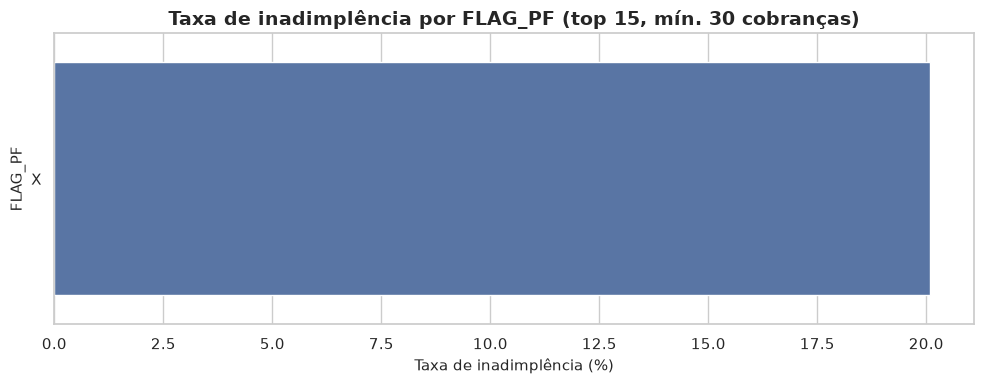

In [14]:
_ = analisar_categorica(df_pag_cad, "FLAG_PF")

### 3.2 `PORTE`

----- PORTE -----
Valores únicos: 3 | Nulos: 2476 (3.2%)


,contagem
PORTE,
MEDIO,29929
GRANDE,29032
PEQUENO,15977
NaN,2476


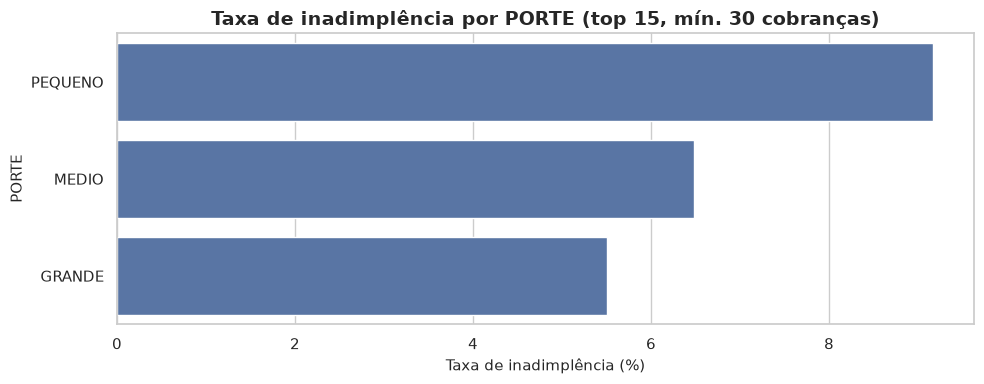

In [15]:
_ = analisar_categorica(df_pag_cad, "PORTE")

### 3.3 `SEGMENTO_INDUSTRIAL`

----- SEGMENTO_INDUSTRIAL -----
Valores únicos: 3 | Nulos: 1417 (1.8%)


,contagem
SEGMENTO_INDUSTRIAL,
Serviços,31638
Comércio,27062
Indústria,17297
NaN,1417


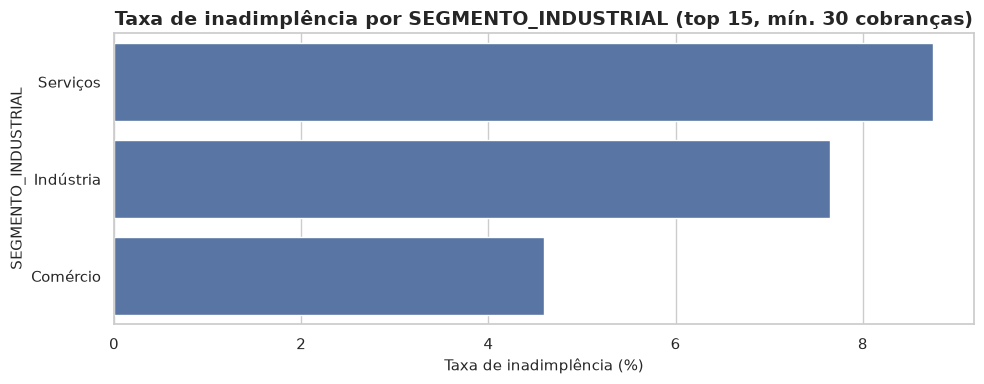

In [16]:
_ = analisar_categorica(df_pag_cad, "SEGMENTO_INDUSTRIAL")

### 3.4 `DOMINIO_EMAIL`

----- DOMINIO_EMAIL -----
Valores únicos: 6 | Nulos: 898 (1.2%)


,contagem
DOMINIO_EMAIL,
YAHOO,25322
GMAIL,21407
HOTMAIL,18681
OUTLOOK,4808
AOL,4456
BOL,1842
NaN,898


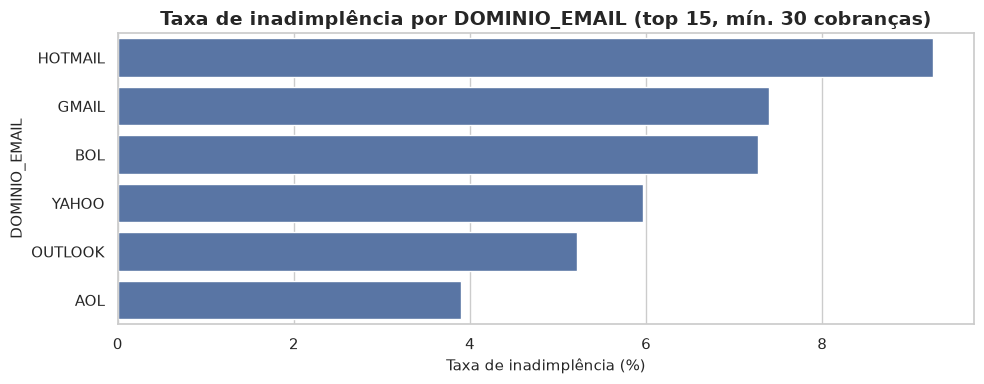

In [17]:
_ = analisar_categorica(df_pag_cad, "DOMINIO_EMAIL")

### 3.5 `CEP_2_DIG`

----- CEP_2_DIG -----
Valores únicos: 90 | Nulos: 0 (0.0%)


,contagem
CEP_2_DIG,
13,3888
35,2845
68,2603
89,2588
86,2135
37,2107
12,2076
78,2067
75,1773


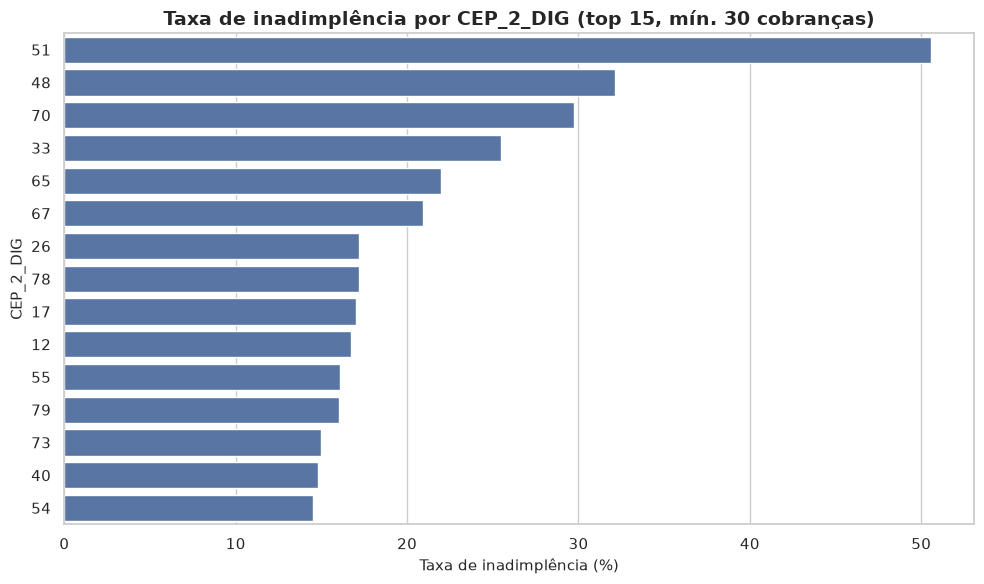

In [18]:
_ = analisar_categorica(df_pag_cad, "CEP_2_DIG")

### 3.6 `DDD`

----- DDD -----
Valores únicos: 78 | Nulos: 7414 (9.6%)


,contagem
DDD,
11,8583
NaN,7414
31,3030
19,2741
21,2672
41,2415
71,2364
62,2324
43,2219


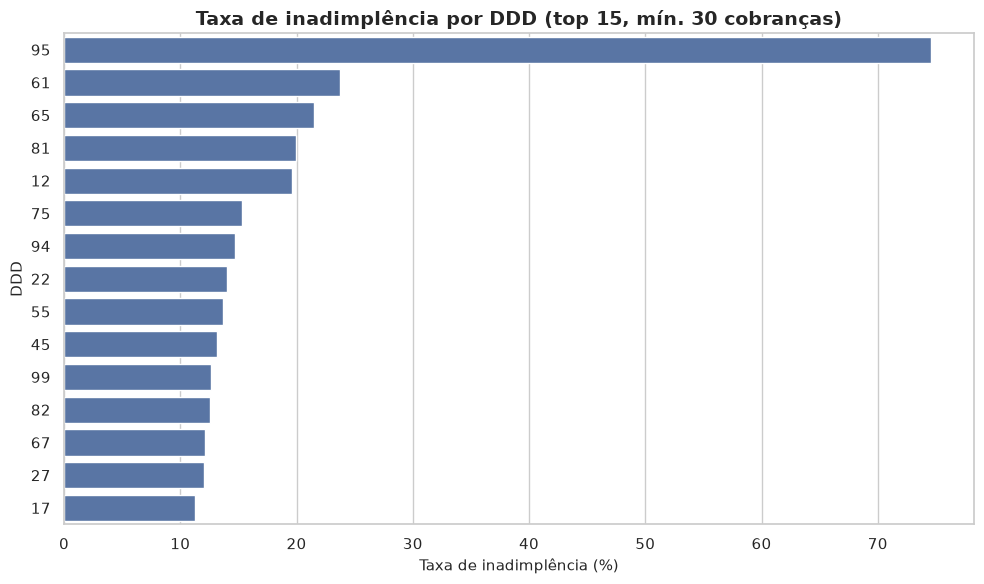

In [19]:
_ = analisar_categorica(df_pag_cad, "DDD")

> **Nota sobre `FLAG_PF`:** a variável assume apenas o valor `X` (indicando pessoa física) ou nulo (pessoa jurídica), com ~95% de nulos na base cadastral. Na prática funciona como uma flag booleana e deve ser tratada como tal na modelagem (ex.: `FLAG_PF_bin = df["FLAG_PF"].notna().astype(int)`).

## 4. Análise das Variáveis Numéricas

Avaliamos a distribuição das variáveis numéricas e sua associação (correlação ponto-bisserial, via `.corr()`) com a variável-alvo.

- `VALOR_A_PAGAR` e `TAXA` já estão em `base_pagamentos_desenvolvimento`.
- `RENDA_MES_ANTERIOR` e `NO_FUNCIONARIOS` vêm de `base_info` e precisam ser unidas por `(ID_CLIENTE, SAFRA_REF)`.

In [20]:
def analisar_numerica(df: pd.DataFrame, col: str, target: str = "inadimplente") -> None:
    print(f"----- {col} -----")
    print(df[col].describe())
    corr = df[col].corr(df[target])
    print(f"Correlação de Pearson com '{target}': {corr:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    sns.histplot(df[col].dropna(), bins=50, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"Distribuição de {col}")
    axes[0].set_xlabel(col)

    sns.boxplot(y=df[col].dropna(), ax=axes[1], color="#4C72B0")
    axes[1].set_title(f"Boxplot de {col}")

    sns.boxplot(x=df[target], y=df[col], ax=axes[2], hue=df[target], palette=["#4C72B0", "#C44E52"], legend=False)
    axes[2].set_title(f"{col} por classe de {target}")
    axes[2].set_xlabel(target)
    axes[2].set_xticks([0, 1])
    axes[2].set_xticklabels(["Adimplente", "Inadimplente"])

    plt.tight_layout()
    plt.show()
    print("\n")

### 4.1 `VALOR_A_PAGAR`

----- VALOR_A_PAGAR -----
count    7.624400e+04
mean     4.659078e+04
std      4.643393e+04
min      1.000000e-01
25%      1.876536e+04
50%      3.475869e+04
75%      6.093384e+04
max      4.400000e+06
Name: VALOR_A_PAGAR, dtype: float64
Correlação de Pearson com 'inadimplente': -0.0882


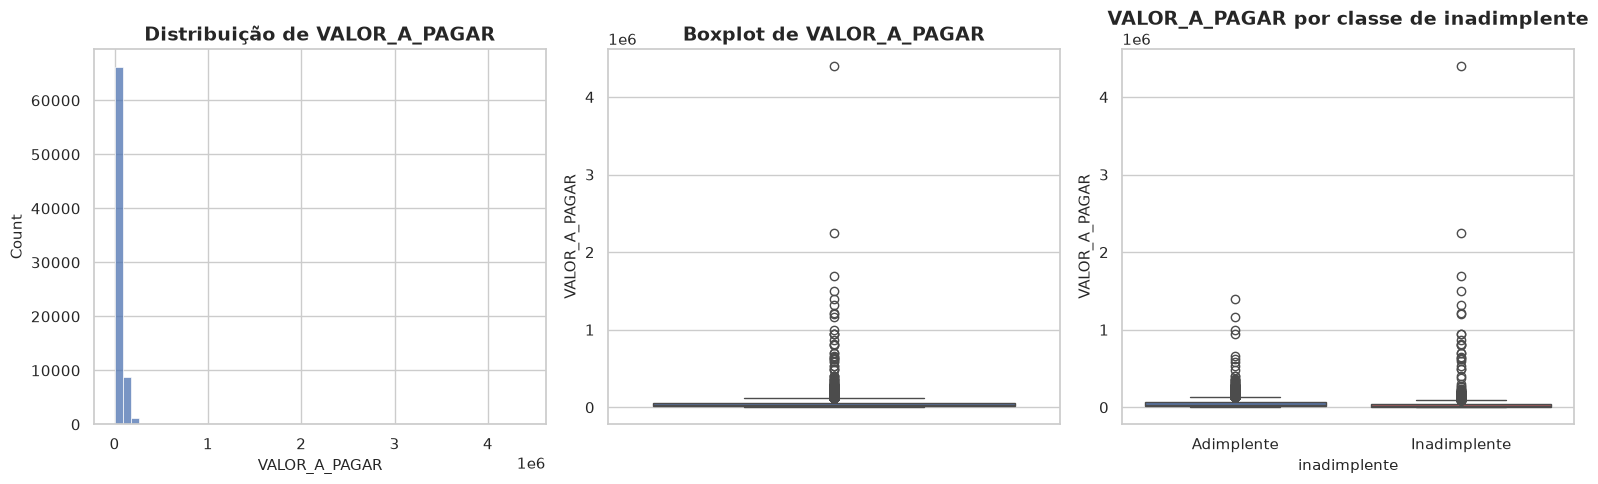

In [21]:
analisar_numerica(df_pag_dev, "VALOR_A_PAGAR")

### 4.2 `TAXA`

----- TAXA -----
count    77414.000000
mean         6.789623
std          1.798225
min          4.990000
25%          5.990000
50%          5.990000
75%          6.990000
max         11.990000
Name: TAXA, dtype: float64
Correlação de Pearson com 'inadimplente': 0.0119


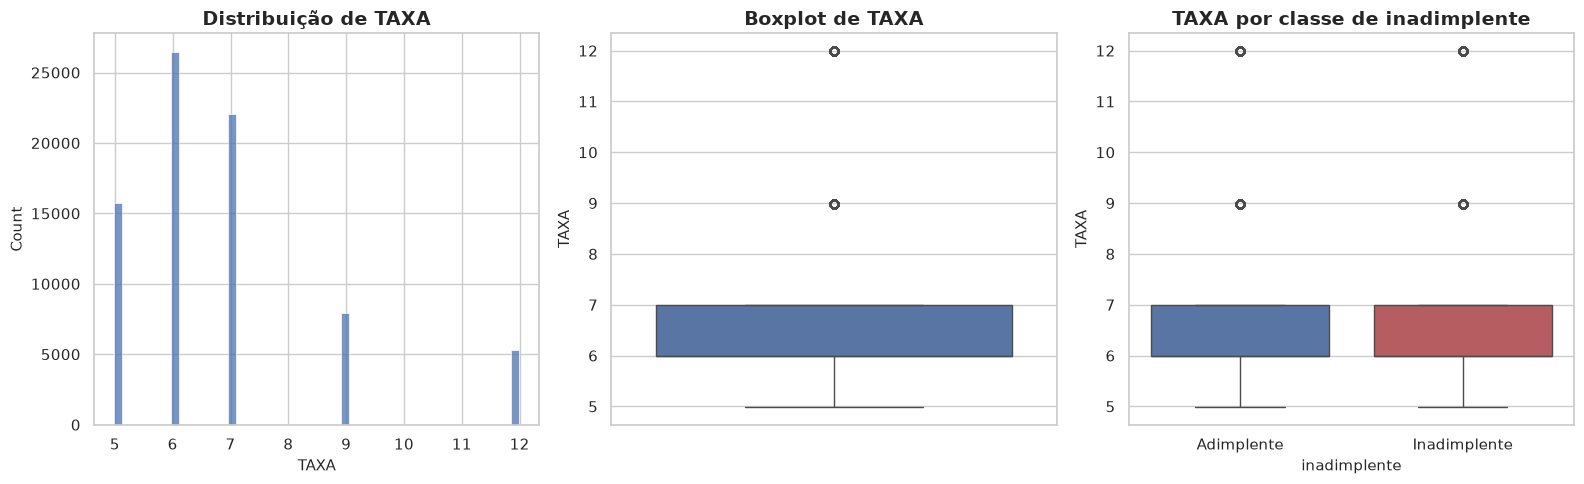

In [22]:
analisar_numerica(df_pag_dev, "TAXA")

### 4.3 `RENDA_MES_ANTERIOR` e `NO_FUNCIONARIOS`

Unimos `base_pagamentos_desenvolvimento` com `base_info` por `(ID_CLIENTE, SAFRA_REF)`.

In [23]:
df_pag_info = df_pag_dev.merge(df_info, on=["ID_CLIENTE", "SAFRA_REF"], how="left")
taxa_match = df_pag_info["RENDA_MES_ANTERIOR"].notna().mean() * 100
print(f"Registros com informação de renda/funcionários encontrada: {taxa_match:.1f}%")

Registros com informação de renda/funcionários encontrada: 92.1%


----- RENDA_MES_ANTERIOR -----
count    7.128200e+04
mean     2.914381e+05
std      2.132932e+05
min      1.050000e+02
25%      1.340742e+05
50%      2.405020e+05
75%      3.962500e+05
max      1.682759e+06
Name: RENDA_MES_ANTERIOR, dtype: float64
Correlação de Pearson com 'inadimplente': -0.0678


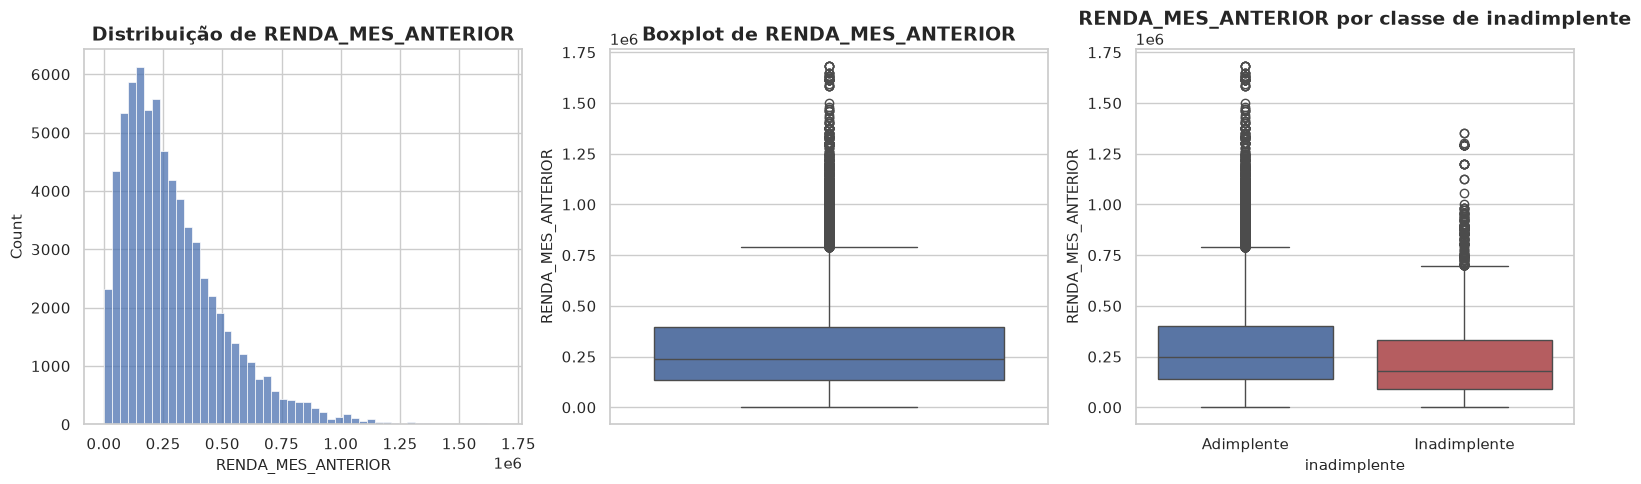

In [24]:
analisar_numerica(df_pag_info, "RENDA_MES_ANTERIOR")

----- NO_FUNCIONARIOS -----
count    69827.000000
mean       117.692812
std         18.779624
min          0.000000
25%        105.000000
50%        118.000000
75%        130.000000
max        198.000000
Name: NO_FUNCIONARIOS, dtype: float64
Correlação de Pearson com 'inadimplente': -0.0172


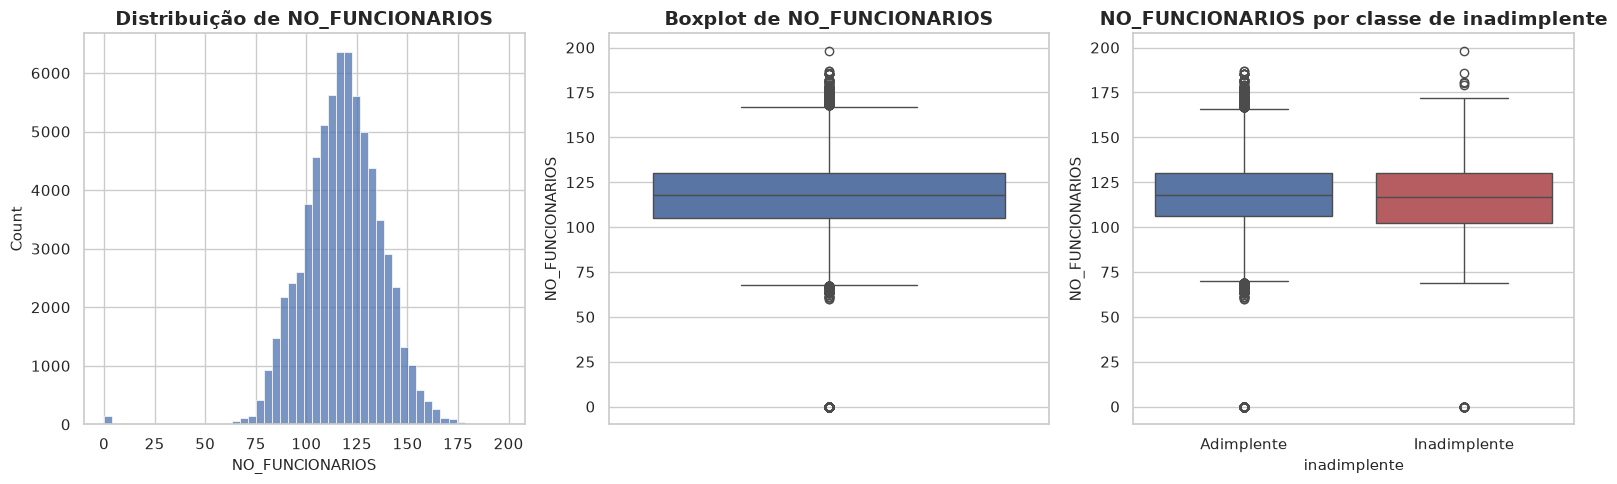

In [25]:
analisar_numerica(df_pag_info, "NO_FUNCIONARIOS")

## 5. Análise Temporal

Avaliamos a cobertura de `SAFRA_REF` em cada base, a evolução da taxa de inadimplência ao longo do tempo e o volume de clientes por safra.

In [26]:
for nome, df in [("base_info", df_info), ("base_pagamentos_desenvolvimento", df_pag_dev), ("base_pagamentos_teste", df_pag_test)]:
    safras = sorted(df["SAFRA_REF"].unique())
    print(f"{nome}: {len(safras)} safras, de {safras[0]} a {safras[-1]}")
print()
print("Observação: base_cadastral não possui SAFRA_REF (é uma base estática, uma linha por cliente).")

base_info: 40 safras, de 2018-09 a 2021-12
base_pagamentos_desenvolvimento: 35 safras, de 2018-08 a 2021-06
base_pagamentos_teste: 5 safras, de 2021-07 a 2021-11

Observação: base_cadastral não possui SAFRA_REF (é uma base estática, uma linha por cliente).


### 5.1 Taxa de inadimplência por safra (`base_pagamentos_desenvolvimento`)

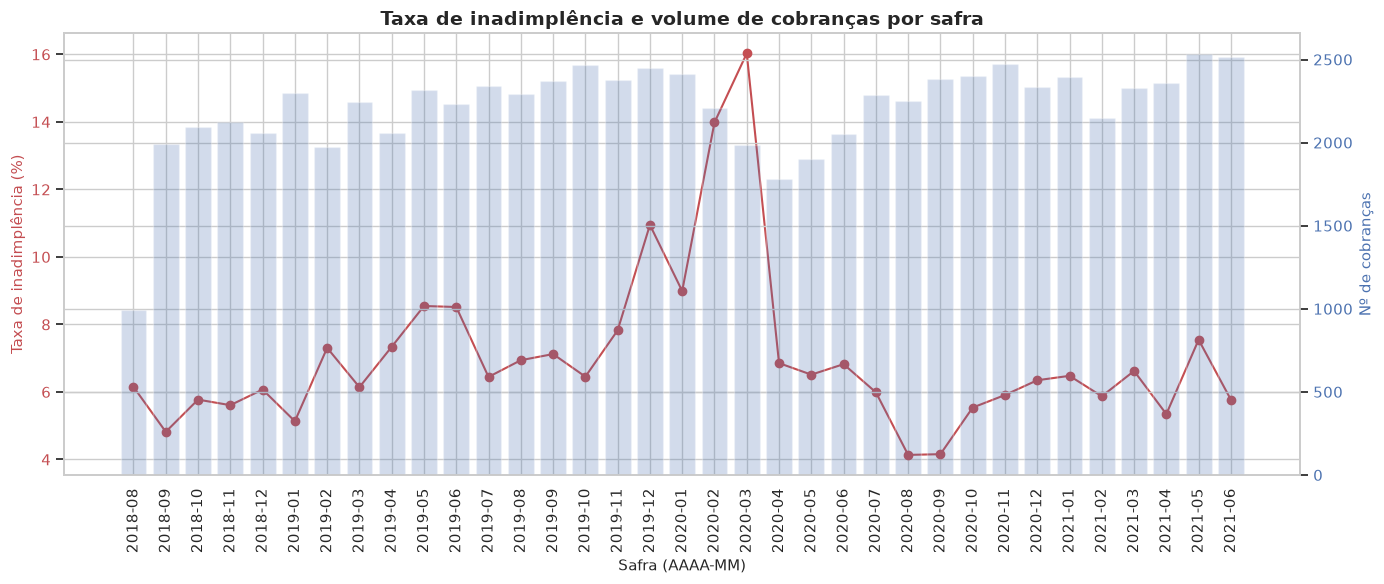

In [27]:
safra_taxa = (
    df_pag_dev.groupby("SAFRA_REF")["inadimplente"]
    .agg(taxa_inadimplencia="mean", n_cobrancas="count")
    .sort_index()
)
safra_taxa["taxa_inadimplencia"] = safra_taxa["taxa_inadimplencia"] * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(safra_taxa.index, safra_taxa["taxa_inadimplencia"], marker="o", color="#C44E52", label="Taxa de inadimplência (%)")
ax1.set_xlabel("Safra (AAAA-MM)")
ax1.set_ylabel("Taxa de inadimplência (%)", color="#C44E52")
ax1.tick_params(axis="y", labelcolor="#C44E52")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.bar(safra_taxa.index, safra_taxa["n_cobrancas"], alpha=0.25, color="#4C72B0", label="Nº de cobranças")
ax2.set_ylabel("Nº de cobranças", color="#4C72B0")
ax2.tick_params(axis="y", labelcolor="#4C72B0")

ax1.set_title("Taxa de inadimplência e volume de cobranças por safra")
fig.tight_layout()
plt.show()

### 5.2 Número de clientes distintos por safra

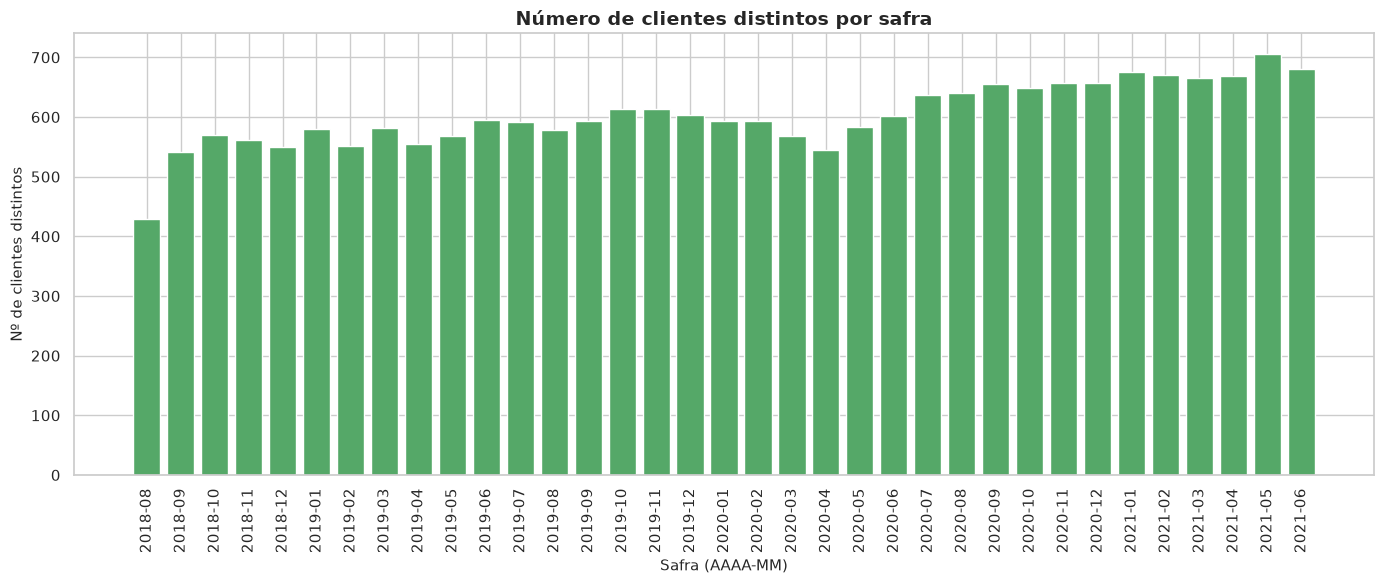

In [28]:
clientes_por_safra = df_pag_dev.groupby("SAFRA_REF")["ID_CLIENTE"].nunique().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(clientes_por_safra.index, clientes_por_safra.values, color="#55A868")
ax.set_title("Número de clientes distintos por safra")
ax.set_xlabel("Safra (AAAA-MM)")
ax.set_ylabel("Nº de clientes distintos")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

### 5.3 Sobreposição temporal entre desenvolvimento e teste

A base de teste cobre as safras mais recentes, **posteriores** ao período coberto pela base de desenvolvimento — reforçando que a validação do modelo deve respeitar a ordem temporal (ex.: validação out-of-time), e não uma divisão aleatória.

In [29]:
print("Última safra em desenvolvimento:", df_pag_dev["SAFRA_REF"].max())
print("Primeira safra em teste:", df_pag_test["SAFRA_REF"].min())
print("Safras em teste:", sorted(df_pag_test["SAFRA_REF"].unique()))

Última safra em desenvolvimento: 2021-06
Primeira safra em teste: 2021-07
Safras em teste: ['2021-07', '2021-08', '2021-09', '2021-10', '2021-11']


## 6. Conclusões da Análise Exploratória

**Qualidade e estrutura dos dados**
- `base_cadastral` tem `ID_CLIENTE` como chave única (1.315 clientes, 1 linha cada), e pode ser unida às demais bases diretamente por `ID_CLIENTE`.
- `FLAG_PF` está ~95% nula e assume um único valor não nulo (`X`); deve ser tratada como flag binária (PF vs. PJ), não como categórica tradicional.
- O merge de `base_pagamentos_desenvolvimento` com `base_info` por `(ID_CLIENTE, SAFRA_REF)` não encontra correspondência para cerca de 5% das cobranças — tratar como dado ausente (ex.: imputação ou categoria "sem informação"), não descartar essas linhas.
- `dias_atraso` apresenta valores extremos (fortemente negativos e muito positivos) que sugerem inconsistências de cadastro de datas; recomenda-se investigar/tratar outliers antes de usar o atraso como feature contínua.
- Neste conjunto de desenvolvimento, `DATA_PAGAMENTO` não possui nulos — a inadimplência observada é definida inteiramente pelo critério de atraso ≥ 5 dias. Isso não isenta o pipeline de tratar nulos nessa coluna, já que a regra de negócio prevê essa possibilidade e ela pode ocorrer em produção.

**Variável-alvo**
- A taxa geral de inadimplência é de aproximadamente **7%**, caracterizando um problema de classificação **desbalanceado**. Isso deve orientar a escolha de métricas (AUC, KS, precision-recall) e, possivelmente, técnicas de balanceamento ou ajuste de threshold.

**Variáveis cadastrais**
- `PORTE`, `SEGMENTO_INDUSTRIAL` e `DOMINIO_EMAIL` mostram diferenças visíveis na taxa de inadimplência entre categorias (ex.: clientes de porte pequeno e do segmento de Serviços tendem a apresentar taxas mais altas), sendo bons candidatos a features categóricas.
- `DDD` e `CEP_2_DIG` têm muitas categorias (79 e 90, respectivamente); algumas com poucas observações. Vale considerar agrupamento geográfico (ex.: região) ou encoding que lide bem com alta cardinalidade (target encoding com regularização, por exemplo).

**Variáveis numéricas**
- `VALOR_A_PAGAR`, `TAXA`, `RENDA_MES_ANTERIOR` e `NO_FUNCIONARIOS` apresentam correlações lineares fracas com o alvo (todas com |correlação| < 0.1). Isso é esperado para inadimplência — sugere que o poder preditivo virá mais de combinações de variáveis e de features derivadas (ex.: histórico do cliente) do que de relações lineares simples com variáveis isoladas.

**Aspecto temporal**
- As bases cobrem períodos distintos: `base_info` de 2018-09 a 2021-12, `base_pagamentos_desenvolvimento` de 2018-08 a 2021-06, e `base_pagamentos_teste` de 2021-07 a 2021-11 — ou seja, o teste é **estritamente posterior** ao desenvolvimento.
- A taxa de inadimplência varia ao longo das safras, o que reforça a necessidade de validar o modelo de forma temporal (ex.: treino em safras mais antigas, validação nas mais recentes), evitando vazamento de informação do futuro para o passado.

**Recomendações para a modelagem**
1. Construir a variável-alvo exatamente como definida aqui, tratando explicitamente o caso de `DATA_PAGAMENTO` nula.
2. Usar validação out-of-time (respeitando `SAFRA_REF`), não split aleatório.
3. Tratar nulos de forma explícita por variável (`FLAG_PF` como binária, renda/funcionários com imputação ou flag de ausência).
4. Investigar e tratar outliers de `dias_atraso` e possivelmente de `VALOR_A_PAGAR`.
5. Explorar features derivadas do histórico do cliente (ex.: taxa de atraso em cobranças anteriores, tendência de renda), já que as variáveis brutas isoladas têm baixo poder preditivo linear.
6. Considerar tratamento específico para variáveis de alta cardinalidade (`DDD`, `CEP_2_DIG`).